In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [2]:
df = pd.read_csv("./experience_vs_salary.csv")

In [3]:
df.head()

,Years_of_Experience,Salary
0,4.37,43395.94
1,13.24,83727.74
2,12.06,81381.71
3,10.05,69018.00
4,12.83,89832.04


In [5]:
df.shape

(500, 2)

In [6]:
df.columns

Index(['Years_of_Experience', 'Salary'], dtype='str')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Years_of_Experience  500 non-null    float64
 1   Salary               500 non-null    float64
dtypes: float64(2)
memory usage: 7.9 KB


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.isnull().sum()

Years_of_Experience    0
Salary                 0
dtype: int64

In [10]:
df.describe()

,Years_of_Experience,Salary
count,500.000000,500.000000
mean,7.846540,59897.310100
std,4.210204,22329.938066
min,0.570000,12723.360000
25%,4.025000,41582.267500
50%,8.120000,60963.780000
75%,11.225000,77953.407500
max,14.990000,107920.300000


In [12]:
X = df[["Years_of_Experience"]]
Y = df["Salary"]

In [13]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.23, random_state=42)

model = LinearRegression()

model.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[4980.72]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['Years_of_Experience']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,2.09e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1


In [15]:
print("Intercept (c): ", model.intercept_)
print("Slope (m): ", model.coef_[0])

Intercept (c):  20901.024867980006
Slope (m):  4980.717580299372


In [ ]:
new_salary = pd.DataFrame({ "Years_of_Experience": [3.56] })

predicted_salary = model.predict(new_salary)

print("Predicted salary based on the experience of 3.56 years: ", predicted_salary[0])

Predicted salary based on the experience of 3.56 years:  38632.37945384577


In [17]:
y_pred = model.predict(X_test)

r2 = r2_score(Y_test, y_pred)
mae = mean_absolute_error(Y_test, y_pred)
mse = mean_squared_error(Y_test, y_pred)
rmse = np.sqrt(mse)

print(f"R square: {r2:.4f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")
print(f"Root Mean Squared Error: {rmse:.2f}")

R square: 0.8453
Mean Absolute Error: 7304.31
Mean Squared Error: 81914788.65
Root Mean Squared Error: 9050.68


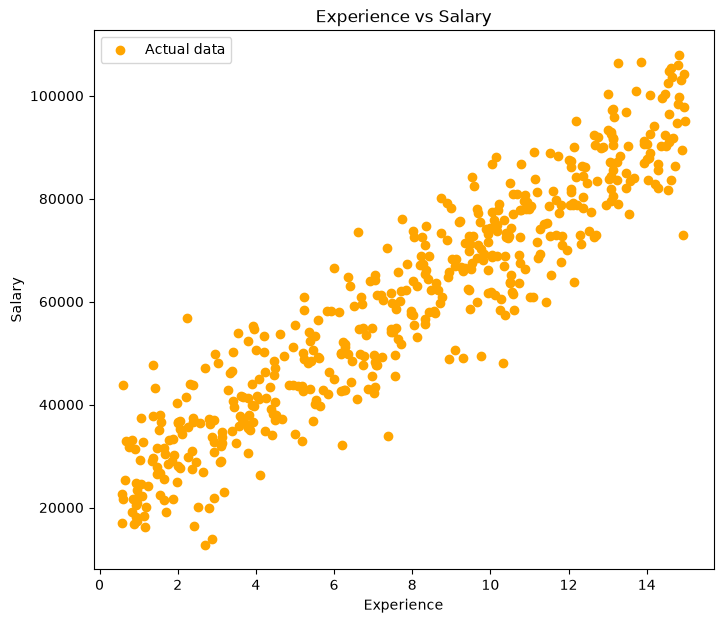

In [18]:
plt.figure(figsize=(8,7))

plt.scatter(X, Y, color="orange", label="Actual data")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")
plt.legend()
plt.show()

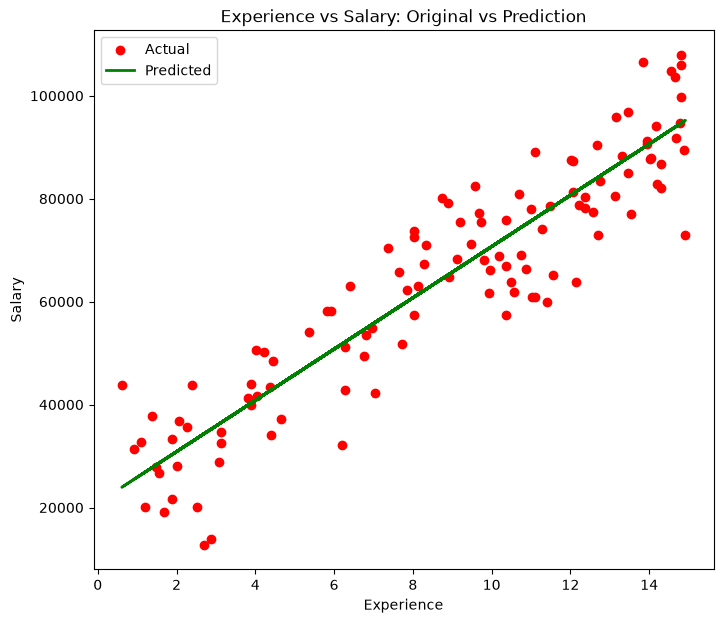

In [19]:
plt.figure(figsize=(8,7))

plt.scatter(X_test, Y_test, color="red", label="Actual")

plt.plot(X_test, y_pred, color="green", linewidth=2, label="Predicted")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary: Original vs Prediction")
plt.legend()
plt.show()

In [20]:
joblib.dump(model, "linear_regression_assign2.pkl")

print("Model saved successfully")

Model saved successfully


In [22]:
X_full = df[["Years_of_Experience"]]

df["Predicted_Salary"] = model.predict(X_full)

print(df[["Years_of_Experience", "Salary", "Predicted_Salary"]].head(10))

   Years_of_Experience    Salary  Predicted_Salary
0                 4.37  43395.94      42666.760694
1                13.24  83727.74      86845.725631
2                12.06  81381.71      80968.478886
3                10.05  69018.00      70957.236550
4                12.83  89832.04      84803.631423
5                13.08  93032.45      86048.810818
6                10.77  67568.40      74543.353208
7                12.64  72533.60      83857.295083
8                10.61  58377.04      73746.438395
9                10.36  75874.14      72501.259000
